In [2]:
from statsmodels.graphics.gofplots import qqplot

from src.Preprocessing import get_preprocessed_data

X_train, X_test, y_train, y_test = get_preprocessed_data(output_as='random_split')

In [3]:
X_train.head()

,Latitude,Longitude,PostalCode,AttachedGarageYN,BathroomsTotalInteger,BedroomsTotal,FireplaceYN,GarageSpaces,LivingArea,MainLevelBedrooms,...,Flooring_Vinyl,Flooring_Laminate,Flooring_SeeRemarks,Flooring_Wood,Flooring_Brick,Flooring_Bamboo,Levels_ThreeOrMore,Levels_Two,Levels_One,Levels_MultiSplit
38274,-0.321713,0.118533,0.230263,0,0.0,1.0,0,0.0,-0.016268,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
13971,-0.420112,0.191335,0.140550,0,1.0,1.0,0,0.0,0.348325,-2.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5891,-0.439796,0.063116,0.160287,0,2.0,0.0,0,0.0,1.378947,-3.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
36023,-0.387666,0.908424,-0.084928,0,0.0,0.0,0,0.0,-0.430622,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75410,-0.905605,0.477600,-0.218900,0,1.0,0.0,0,0.0,0.056459,-3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,0.0


In [4]:
cols_with_na = []
for col in X_train.columns:
    na_count = X_train[col].isna().sum()
    print(f'{col}: {na_count} NAs')
    if na_count < 100:
        cols_with_na.append(col)



Latitude: 0 NAs
Longitude: 0 NAs
PostalCode: 0 NAs
AttachedGarageYN: 0 NAs
BathroomsTotalInteger: 0 NAs
BedroomsTotal: 0 NAs
FireplaceYN: 0 NAs
GarageSpaces: 0 NAs
LivingArea: 0 NAs
MainLevelBedrooms: 0 NAs
NewConstructionYN: 0 NAs
ParkingTotal: 0 NAs
PoolPrivateYN: 0 NAs
Stories: 0 NAs
ViewYN: 0 NAs
YearBuilt: 0 NAs
LotSizeAcres: 0 NAs
LotSizeArea: 0 NAs
LotSizeSquareFeet: 0 NAs
AssociationFee: 0 NAs
DaysOnMarket: 0 NAs
sin_closed_date: 0 NAs
Flooring_Concrete: 0 NAs
Flooring_Tile: 0 NAs
Flooring_Stone: 0 NAs
Flooring_Carpet: 0 NAs
Flooring_Vinyl: 0 NAs
Flooring_Laminate: 0 NAs
Flooring_SeeRemarks: 0 NAs
Flooring_Wood: 0 NAs
Flooring_Brick: 0 NAs
Flooring_Bamboo: 0 NAs
Levels_ThreeOrMore: 0 NAs
Levels_Two: 0 NAs
Levels_One: 0 NAs
Levels_MultiSplit: 0 NAs


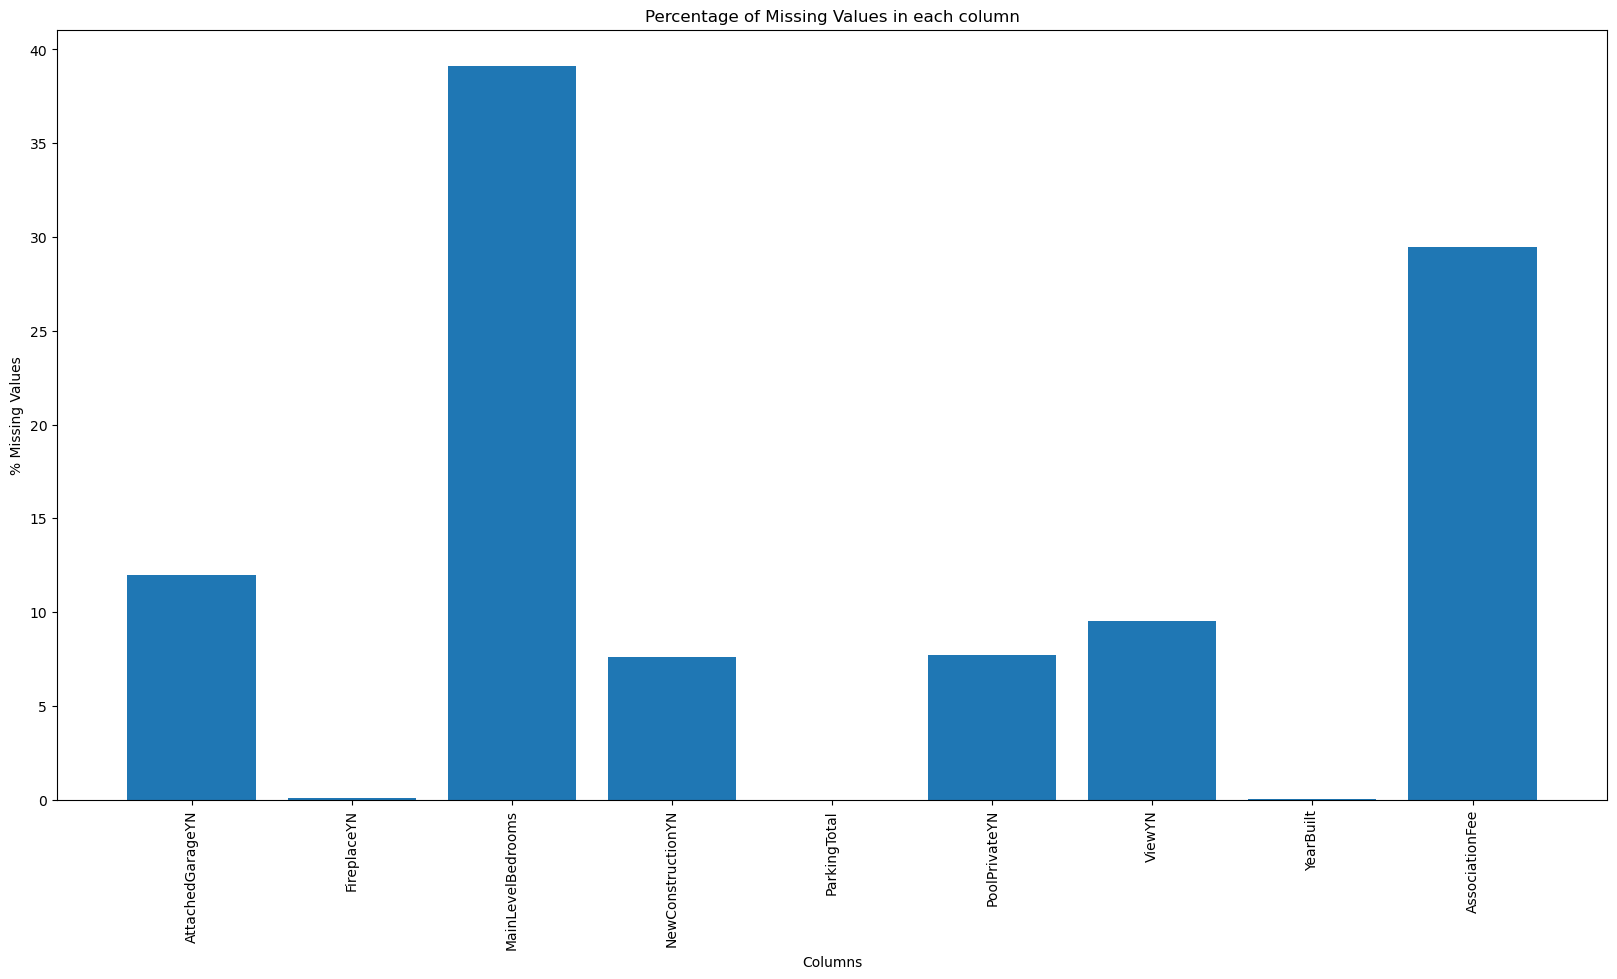

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

def column_na_plot(df: pd.DataFrame):
    is_na = []
    data = df.copy()
    for column in data.columns:
        is_na_perc = data[column].isna().sum() * 100 / len(data[column])
        if is_na_perc > 0:
            is_na.append( is_na_perc )
        else:
            data.drop(column, axis=1, inplace=True)
    plt.figure(figsize = (20,10))
    plt.bar(x=data.columns, height=is_na)
    plt.xticks(rotation=90)
    plt.xlabel('Columns')
    plt.ylabel('% Missing Values')
    plt.title('Percentage of Missing Values in each column')
    plt.show()

column_na_plot(X_train)

### Assume values for missing value of YN columns are N

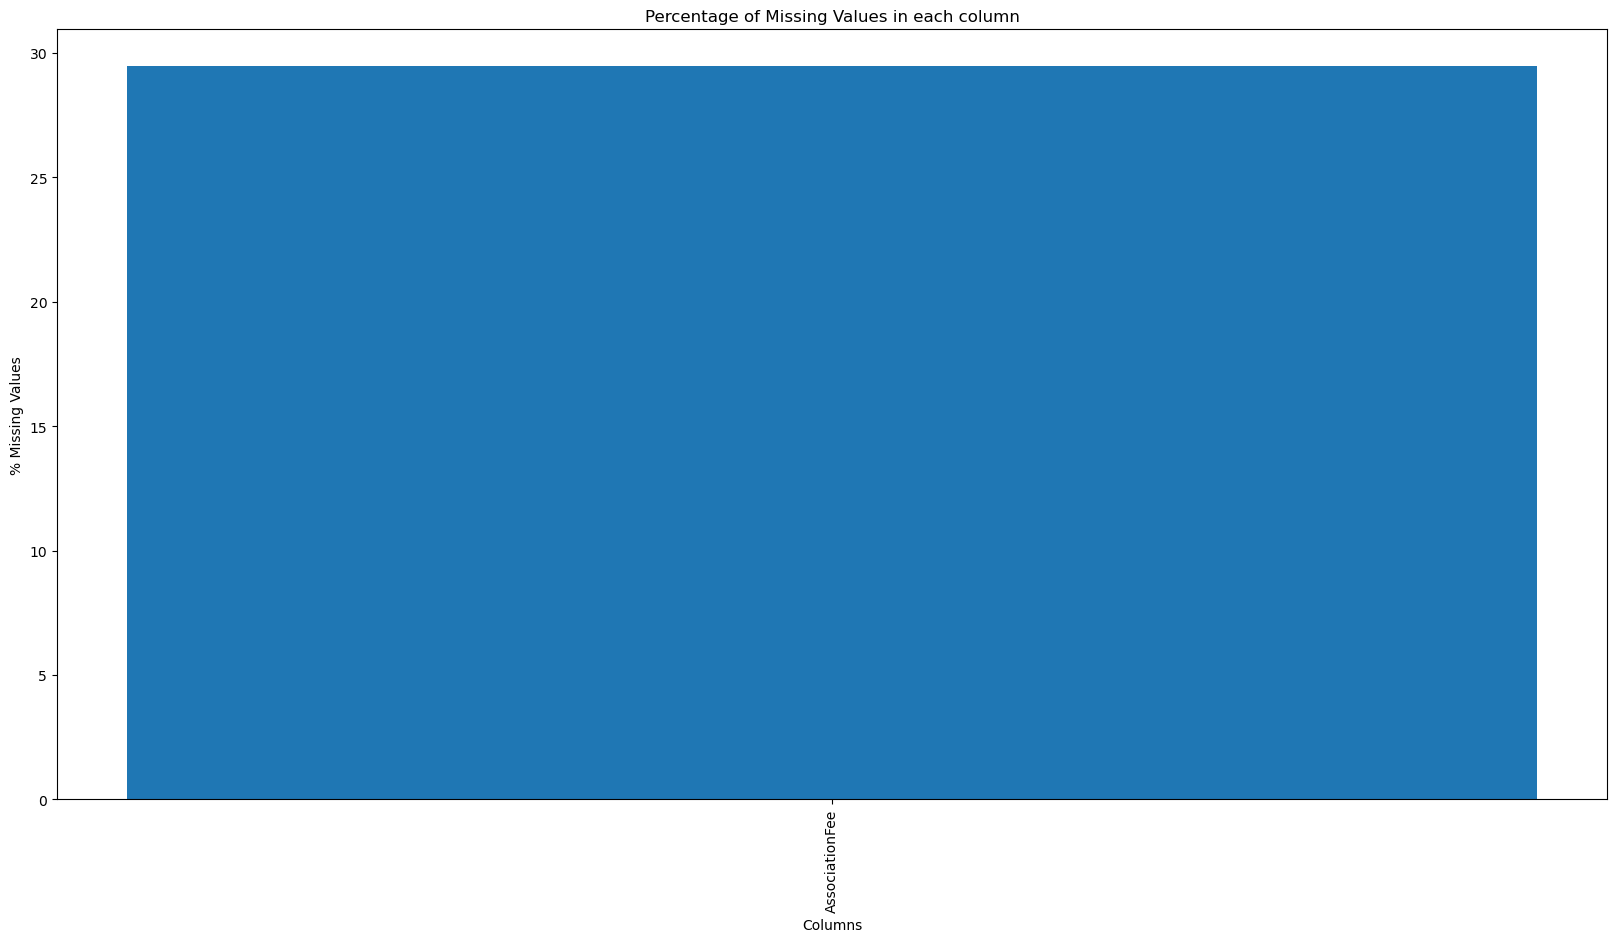

In [6]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="most_frequent")
cols_to_impute = ['AttachedGarageYN', 'FireplaceYN', 'NewConstructionYN', 'PoolPrivateYN', 'ViewYN', 'ParkingTotal', 'YearBuilt', 'MainLevelBedrooms']

X_train[cols_to_impute] = imputer.fit_transform(X_train[cols_to_impute])
X_test[cols_to_impute] = imputer.fit_transform(X_test[cols_to_impute])

column_na_plot(X_train)

## Assume houses with missing HOA are houses with no HOA

In [7]:
def fill_zeros(x):
    if pd.isna(x):
        return 0
    else:
        return x

X_train['AssociationFee'] = X_train['AssociationFee'].apply(fill_zeros)
X_test['AssociationFee'] = X_test['AssociationFee'].apply(fill_zeros)

In [8]:
cols_with_na = []
for col in X_train.columns:
    na_count = X_train[col].isna().sum()
    print(f'{col}: {na_count} NAs')
    if na_count < 100:
        cols_with_na.append(col)

Latitude: 0 NAs
Longitude: 0 NAs
PostalCode: 0 NAs
AttachedGarageYN: 0 NAs
BathroomsTotalInteger: 0 NAs
BedroomsTotal: 0 NAs
FireplaceYN: 0 NAs
GarageSpaces: 0 NAs
LivingArea: 0 NAs
MainLevelBedrooms: 0 NAs
NewConstructionYN: 0 NAs
ParkingTotal: 0 NAs
PoolPrivateYN: 0 NAs
Stories: 0 NAs
ViewYN: 0 NAs
YearBuilt: 0 NAs
LotSizeAcres: 0 NAs
LotSizeArea: 0 NAs
LotSizeSquareFeet: 0 NAs
AssociationFee: 0 NAs
DaysOnMarket: 0 NAs
sin_closed_date: 0 NAs
Flooring_SeeRemarks: 0 NAs
Flooring_Tile: 0 NAs
Flooring_Stone: 0 NAs
Flooring_Vinyl: 0 NAs
Flooring_Bamboo: 0 NAs
Flooring_Brick: 0 NAs
Flooring_Carpet: 0 NAs
Flooring_Wood: 0 NAs
Flooring_Laminate: 0 NAs
Flooring_Concrete: 0 NAs
Levels_Two: 0 NAs
Levels_One: 0 NAs
Levels_MultiSplit: 0 NAs
Levels_ThreeOrMore: 0 NAs


# Eval with Random Forest

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

rf = RandomForestRegressor(n_estimators=100, max_depth=20)

result = rf.fit(X=X_train, y=y_train)
result

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [14]:
y_pred = rf.predict(X_test)

from sklearn.metrics import r2_score, make_scorer
from sklearn.model_selection import cross_validate
import numpy as np

def mdape(y_pred, y_test):
    error = abs(y_test - y_pred)
    return np.median((error * 100) / y_test)

mdape_score = make_scorer(mdape, greater_is_better=False)

r2_result = cross_validate(rf, X=X_test, y=y_test, scoring=['r2', 'neg_median_absolute_error'], cv=5)
mdape_result = mdape(y_pred, y_test)

# print(f'MdAPE: {mdape_result}%')
print(f'R2: {r2_result}')

MdAPE: 0.5913310389333973%
R2: {'fit_time': array([4.37640905, 4.37325597, 4.32907009, 4.38217902, 4.25227904]), 'score_time': array([0.03671193, 0.03175712, 0.03176308, 0.03226209, 0.03058887]), 'test_r2': array([0.80698431, 0.84153681, 0.84973397, 0.85171412, 0.79432904]), 'test_neg_median_absolute_error': array([-0.10988931, -0.09386972, -0.09600795, -0.09670434, -0.11147099])}


In [15]:
def real_world_mdape(y_pred_log, y_test_log):
    # Convert back to original scale (e.g., Dollars)
    y_pred_actual = np.exp(y_pred_log)
    y_test_actual = np.exp(y_test_log)

    # Calculate percentage error on the actual values
    error = np.abs(y_test_actual - y_pred_actual)
    return np.median(error / y_test_actual) * 100

# Run this on your results
actual_mdape = real_world_mdape(y_pred, y_test)
print(f'Actual Price MdAPE: {actual_mdape:.2f}%')

Actual Price MdAPE: 8.09%


# The results are not good lol

Text(0.5, 0, 'residual')

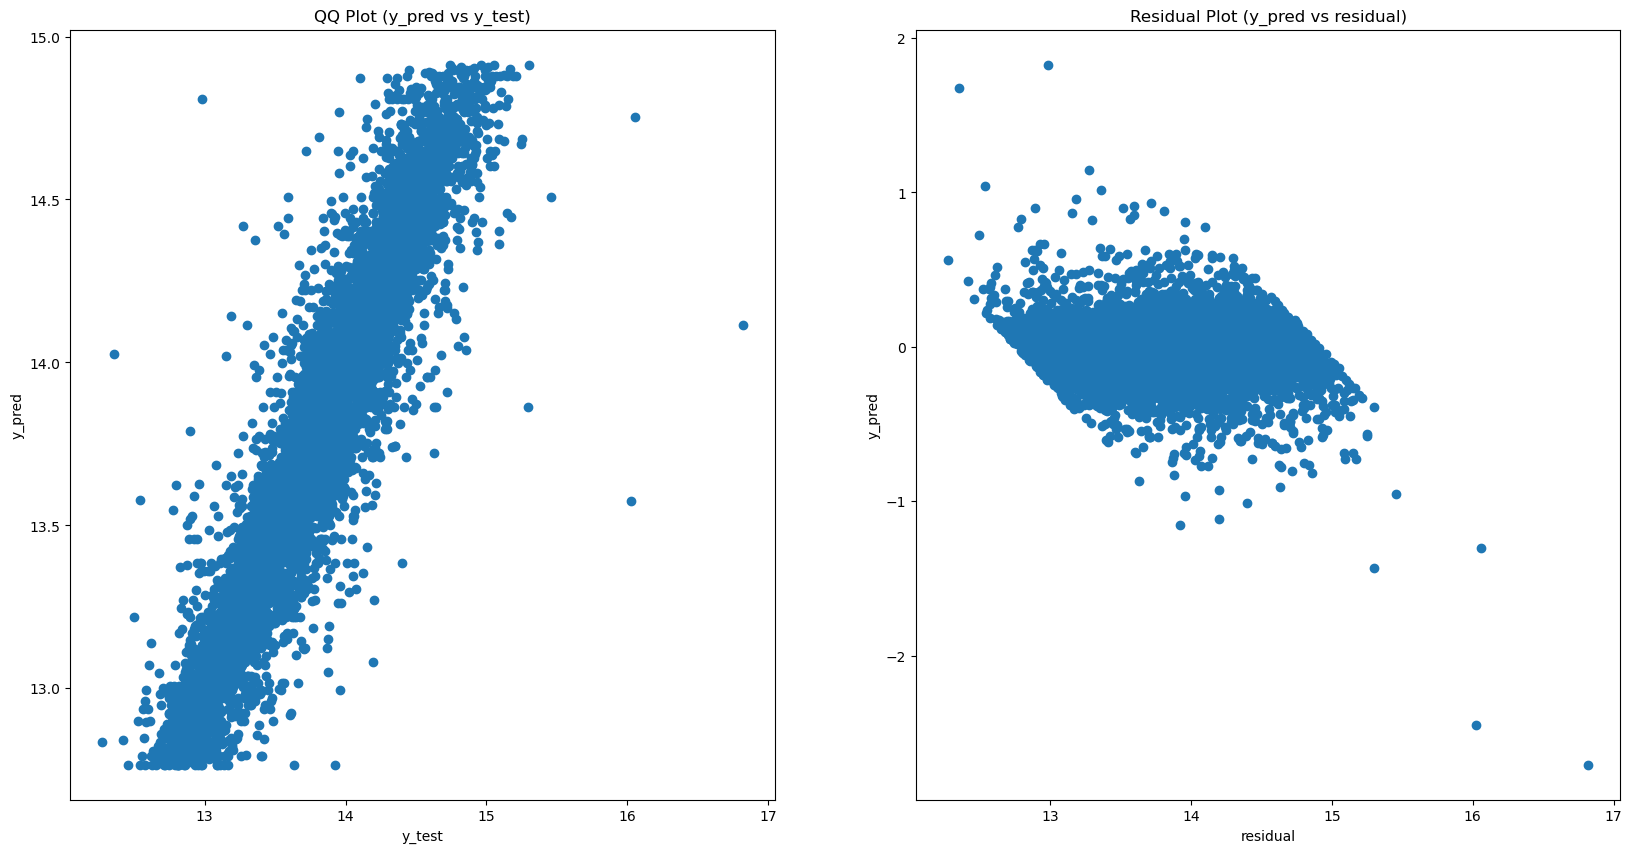

In [11]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(20,10))

axs[0].scatter(x=y_pred, y=y_test)
axs[0].set_title("QQ Plot (y_pred vs y_test)")
axs[0].set_ylabel("y_pred")
axs[0].set_xlabel("y_test")


axs[1].scatter(x=y_pred, y=y_test-y_pred)
axs[1].set_title("Residual Plot (y_pred vs residual)")
axs[1].set_ylabel("y")
axs[1].set_xlabel("residual")

In [1]:
import shap

explainer = shap.TreeExplainer(rf)
shap_val = explainer.shap_values(X_test[:1000])
shap.summary_plot

ModuleNotFoundError: No module named 'shap'

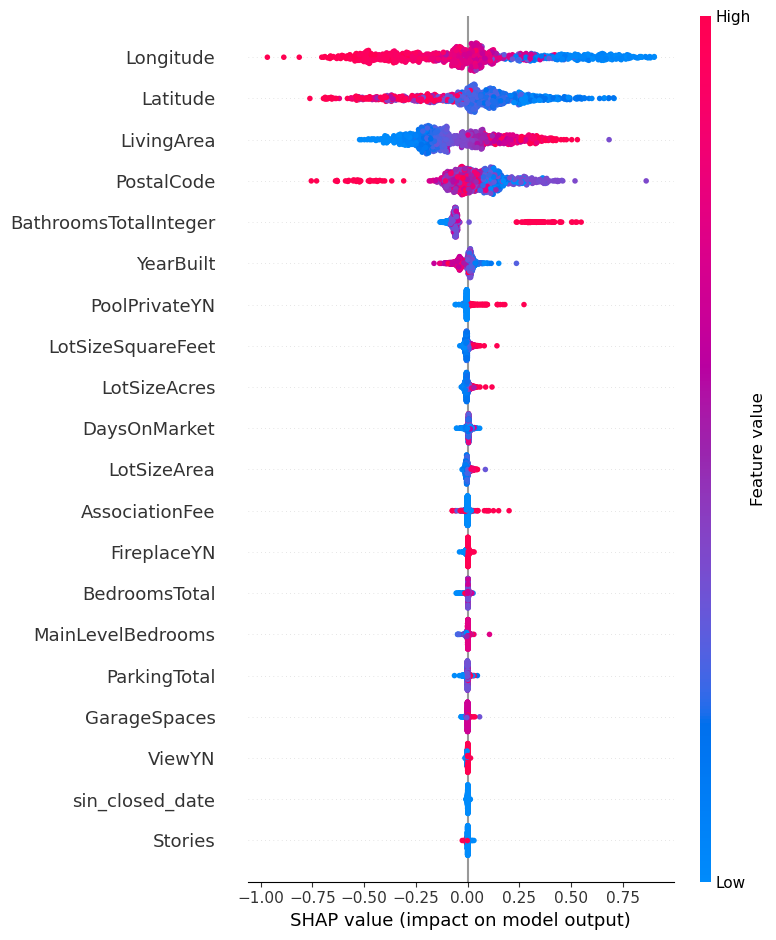

In [13]:
shap.summary_plot(shap_val, X_test[:1000])

### Geo info seems to have the most impact on log_price

In [3]:
from src.Preprocessing import get_unprocessed_data

df = get_unprocessed_data()
df['Flooring'].unique()

Retrieved 186296 rows of data from the database.


<StringArray>
[                                     nan,
                        'Carpet,Laminate',
                            'Carpet,Tile',
                       'Carpet,Tile,Wood',
                          'Laminate,Tile',
                               'Laminate',
                           'Carpet,Vinyl',
                 'Carpet,Tile,Vinyl,Wood',
                                   'Tile',
                                   'Wood',
 ...
  'Carpet,Laminate,Stone,Tile,Vinyl,Wood',
                 'Bamboo,SeeRemarks,Wood',
       'Carpet,Laminate,Stone,Vinyl,Wood',
                 'Bamboo,Tile,Vinyl,Wood',
        'Bamboo,Laminate,Stone,Tile,Wood',
           'Brick,Carpet,Stone,Tile,Wood',
  'Carpet,Laminate,SeeRemarks,Stone,Tile',
 'Concrete,Laminate,SeeRemarks,Tile,Wood',
  'Carpet,Laminate,SeeRemarks,Stone,Wood',
         'Concrete,SeeRemarks,Tile,Vinyl']
Length: 283, dtype: str

In [1]:
from src.Preprocessing import get_preprocessed_data

X_train, X_test, y_train, y_test = get_preprocessed_data(output_as='random_split')

Creating database directory...
Data folders created.
Database file found. Initializing connection...
No new CSVs to import to the database. Returning connection...
Connection initialized.
Retrieved 186296 rows of data from the database.
Processing 186296 rows of data.
Finished parsing PostalCode.
Finished cyclical encoding CloseDate.
Finished transforming abs(DaysOnMarket).
Finished transforming log(ClosePrice).
Found pre-trained encoder model for Flooring. Returning artifact...
Encoding Flooring...
Encoded Flooring with MultiLabelBinarizer.
Finished de-stacking and encoding Flooring.
Not found pre-trained encoder model for Levels.
Created and saved encoder model for Levels at C:\Users\Eddie Nguyen\PycharmProjects\California-House-Price-Prediction\Data\Artifacts\Levels_encoder_model.joblib
Encoding Levels...
Encoded Levels with MultiLabelBinarizer.
Finished de-stacking and encoding Levels.
Finished feature engineering.
Found pre-trained imputer model for YearBuilt. Returning artifact..

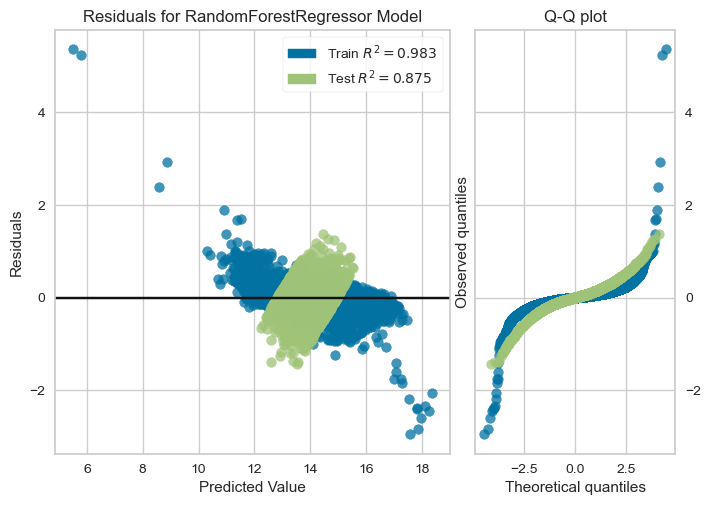

<Axes: title={'center': 'Residuals for RandomForestRegressor Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [9]:
from yellowbrick.regressor import ResidualsPlot
from sklearn.ensemble import RandomForestRegressor

# Huiyu's best RF model from GridSearchCV
rf = RandomForestRegressor(n_estimators=200, min_samples_split=2, min_samples_leaf=1, max_features='sqrt')

visualizer = ResidualsPlot(rf, qqplot=True, hist=False)
visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show()


# Model Evaluation using metrics (Training set)

In [11]:
from validation import evaluate

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
evaluate(y_pred=y_pred, y_test=y_test)

R2: 0.8733
MdAPE (log-scale): 0.64%
MdAPE (dollar-scale): 8.73%


C:\Users\Eddie Nguyen\.conda\envs\IDX\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


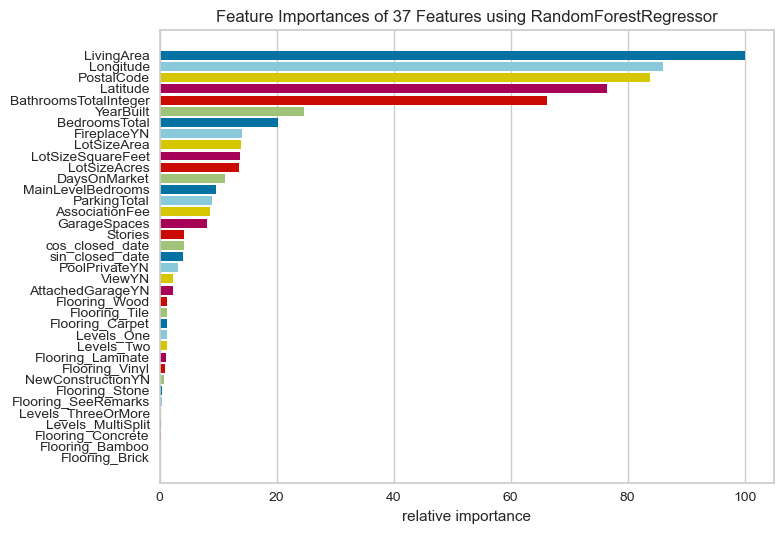

<Axes: title={'center': 'Feature Importances of 37 Features using RandomForestRegressor'}, xlabel='relative importance'>

In [20]:

from yellowbrick.model_selection import FeatureImportances
visualizer = FeatureImportances(rf)
visualizer.fit(X_train, y_train)
visualizer.show()


# Model Evaluation (Evaluation set Jan 26)


In [18]:
from Preprocessing import get_eval_data

eval_df = get_eval_data()
target = eval_df['log_price']
eval_df.drop(columns=['log_price'], inplace=True)

Retrieved 8542 rows of data from the database.
Processing 8542 rows of data.
Finished parsing PostalCode.
Finished cyclical encoding CloseDate.
Finished transforming abs(DaysOnMarket).
Finished transforming log(ClosePrice).
Found pre-trained encoder model for Flooring. Returning artifact...
Encoding Flooring...
Encoded Flooring with MultiLabelBinarizer.
Finished de-stacking and encoding Flooring.
Found pre-trained encoder model for Levels. Returning artifact...
Encoding Levels...
Encoded Levels with MultiLabelBinarizer.
Finished de-stacking and encoding Levels.
Finished feature engineering.
Found pre-trained imputer model for YearBuilt. Returning artifact...
Finished imputation for YearBuilt.
Found pre-trained imputer model for BedroomsTotal. Returning artifact...
Finished imputation for BedroomsTotal.
Found pre-trained imputer model for BathroomsTotalInteger. Returning artifact...
Finished imputation for BathroomsTotalInteger.
Finished imputing ['YearBuilt', 'BedroomsTotal', 'Bathroom

In [19]:
y_pred = rf.predict(eval_df)
evaluate(y_pred=y_pred, y_test=target)

R2: 0.8393
MdAPE (log-scale): 0.79%
MdAPE (dollar-scale): 10.78%


C:\Users\Eddie Nguyen\AppData\Local\Temp\ipykernel_44568\4219590736.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  get_eval_plots(y_pred, target).show()


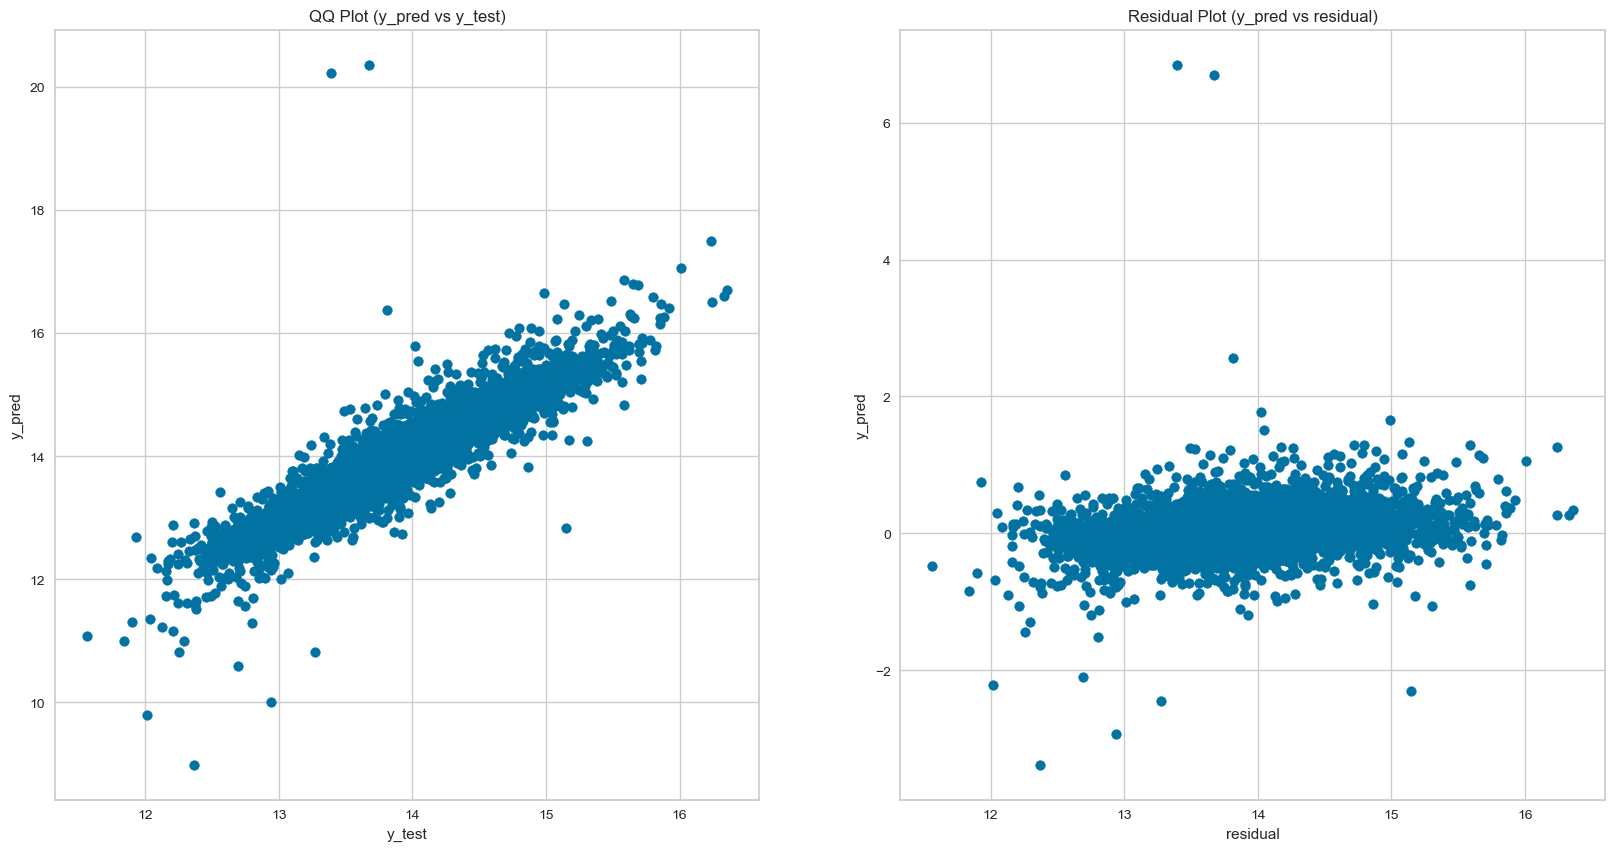

In [17]:
from validation import get_eval_plots

get_eval_plots(y_pred, target).show()

# Model Performance

## 1. Predictive Accuracy
The model demonstrates strong linear alignment across the primary target range ($12$ to $16$ on the log scale). The tight grouping in the $y_{pred}$ vs. $y_{test}$ plot indicates that the current feature engineering has successfully captured the underlying signal of the dataset.
## 2. Residual Analysis
### Central Tendency:
The majority of residuals are centered around zero with constant variance (homoscedasticity) within the "trust zone," suggesting the model is unbiased for the bulk of the data.
### Outlier Detection:
Two significant outliers were identified with high positive residuals. These represent extreme cases where the model significantly under-predicted the target. These can be addressed via input clipping or robust filtering during the preprocessing stage.